# This script runs the Example 1 on OpenTRIM (`opentrim`) from a Python notebook

In this notebook we create the configuration for example 1 and run it through Python.


It assumes `opentrim` is available on your `PATH`. If it is not, set `exe`
to the full path (example in the comment below).

In [9]:
from pathlib import Path   # convenient, cross-platform path handling (files, joining paths, etc.)
import json                # encode/decode JSON (opentrim -t output, writing config.json)

import subprocess          # run the external `opentrim` executable and capture stdout/stderr
import tempfile            # create a temporary directory to run opentrim without polluting your repo

from typing import Any, Dict  # type hints for config dictionaries, helps readability in notebooks

import h5py                # read the HDF5 output file produced by opentrim (result.h5)
import numpy as np         # convert datasets to NumPy arrays, manipulate/flatten/slice for plotting
import matplotlib.pyplot as plt  # plot results from datasets using Matplotlib

The code below generates the template json file.

In [10]:
exe = "opentrim"
cmd_template = [exe, "-t"]

template_run = subprocess.run(
    cmd_template,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()  # raises if opentrim -t failed
# Start Config from the template
Config: Dict[str, Any] = json.loads(template_run.stdout)



## Customize the Config in the code below:

In [ ]:
# Example edits:
Config["Transport"]["flight_path_type"] = "Variable"

Config["IonBeam"]["spatial_distribution"]["center"] = [
                0.0,
                5000.0,
                5000.0]
Config["Target"]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Target"]["cell_count"] = [
            100,
            1,
            1
        ]
Config["Target"]["regions"][0]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Output"]["title"] = "1 MeV H on Fe example"
Config["Output"]["outfilename"] = "Example1"
Config["Output"]["store_exit_events"] = True
Config["Output"]["store_pka_events"] = True

Config["Run"]["threads"] = 0
Config["Run"]["max_no_ions"] = 20000


If your PATH is set up correctly, this is enough:

returncode: 0
stdout:
 Parsing JSON config from config.json
Starting simulation '1 MeV H on Fe example'...


║                                        ║  0%║ETC 00:00:00║
║██████████████▍                         ║ 35%║ETC 00:00:01║
║████████████████████████████▉           ║ 72%║ETC 00:00:01║
║████████████████████████████████████████║100%║ETC 00:00:00║
║████████████████████████████████████████║100%║ETC 00:00:00║

Completed 20000 ion histories.
Threads: 4
CPU time (s):  2.19409,	Ions/cpu-s:  9115.38
Wall time (s): 0.606758,	Ions/wall-s: 32962
Storing results in result.h5 ... OK.

stderr:
 

Opening: /tmp/opentrim_cnbehnwr/result.h5


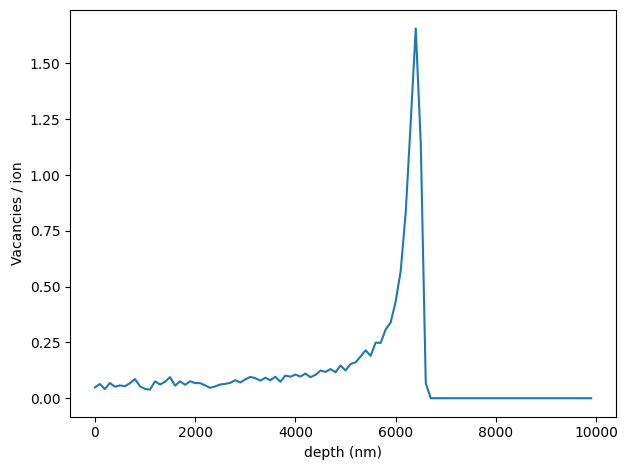

In [12]:
# --- Run opentrim in an isolated temp directory, then read+plot the result ---

with tempfile.TemporaryDirectory(prefix="opentrim_") as tmp:
    tmpdir = Path(tmp)
    h5_path = tmpdir / "result.h5"

    config_path = tmpdir / "config.json"
    config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

    cmd = [exe, "-f", "config.json", "-o", "result", "-s", "42"]
    result = subprocess.run(
        cmd,
        cwd=str(tmpdir),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        stdin=subprocess.DEVNULL,
        timeout=120,
    )

    print("returncode:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    result.check_returncode()

    if not h5_path.exists():
        raise FileNotFoundError(f"Expected output file not found: {h5_path}")

    print("\nOpening:", h5_path)

    with h5py.File(h5_path, "r") as f:
        # Read datasets
        X = np.asarray(f["/target/grid/X"][...])  # shape (101,)
        Vacancies = np.asarray(f["/tally/damage_events/Vacancies"][...])  # shape (2,100,1,1)

        # Build x/y as requested
        x = X[0:100]                       # X(0:1:99) -> first 100 points
        y = Vacancies[1, 0:100, 0, 0]      # Vacancies[1,0:1:99,0,0]

        # Plot
        plt.figure()
        plt.plot(x, y)
        plt.xlabel("depth (nm)")
        plt.ylabel("Vacancies / ion")
        plt.tight_layout()
        plt.show()